In [1]:
from numpy.testing.print_coercion_tables import print_new_cast_table

from DataScraper import *
from GraphVisualizations import *
import networkx.classes.function as fn

def nodes_per_attribute_val(G, attribute, attribute_name):
    continents = nx.get_node_attributes(G, attribute_name)

    count = 0
    for airport in continents.values():
        if airport == attribute:
            count += 1

    return count

def edges_between(G, con1, con2, attribute):
    count = 0
    for node1, node2 in G.edges():
        c1 = G.nodes[node1][attribute]
        c2 = G.nodes[node2][attribute]
        if (c1 == con1 and c2 == con2) or (c1 == con2 and c2 == con1):
            count += 1

    return count

def generate_clusters_by_node_list(G, node_list, attribute):
    C = nx.Graph()
    C.add_nodes_from(node_list)

    # Store number of airports in each cluster
    for node in node_list:
        count = nodes_per_attribute_val(G, node, attribute)
        C.nodes[node]["airports"] = count

    # Edges Between
    for node1, node2 in G.edges():
        c1 = G.nodes[node1][attribute]
        c2 = G.nodes[node2][attribute]
        if c1 in node_list and c2 in node_list and c1 != c2:
            edges = edges_between(G, c1, c2, attribute)
            if edges > 0:
                C.add_edge(c1, c2, weight=edges)

    return C

# Create subgraph and add nodes as names of countries
G = make_graph()


countries = set()
for node in G.nodes():
    # if G.nodes[node]["continent"] == "South America": # Modify for continent specific country level clustering
        country = G.nodes[node]['country']
        countries.add(country)

C = generate_clusters_by_node_list(G, countries, 'country')

\### Adding Population Attributes

In [2]:
country_pop = {}

with open("./data/archive/country_population.csv", newline="", encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader, None)  # Skip header

    for row in reader:
        country = row[2].strip()
        if not country or country == r"\N":
            continue

        population = row[9].strip()
        if not population or population == r"\N":
            continue

        country_pop[country] = {
            "population": population
        }

nx.set_node_attributes(C, country_pop)

nodes_without_pop = [
    n for n, attrs in C.nodes(data=True)
    if "population" not in attrs
]

add_pop = {node: {"population": 0} for node in nodes_without_pop}

add_pop["Cape Verde"]["population"] = 514104
add_pop["Czech Republic"]["population"] = 10671870
add_pop["Swaziland"]["population"] = 1179874
add_pop["Puerto Rico"]["population"] = 3302691
add_pop["Iran"]["population"] = 87051648
add_pop["Micronesia"]["population"] = 110282
add_pop["Somalia"]["population"] = 16030971
add_pop["Turkey"]["population"] = 82579440
add_pop["Saint Lucia"]["population"] = 177661
add_pop["Congo (Brazzaville)"]["population"] = 5616661
add_pop["Saint Kitts and Nevis"]["population"] = 46952
add_pop["Venezuela"]["population"] = 28938098
add_pop["East Timor"]["population"] = 1300945
add_pop["Brunei"]["population"] = 442680
add_pop["Congo (Kinshasa)"]["population"] = 92947442
add_pop["Gambia"]["population"] = 2456844
add_pop["South Korea"]["population"] = 51764822
add_pop["Burma"]["population"] = 52640713
add_pop["Macedonia"]["population"] = 1876262
add_pop["Slovakia"]["population"] = 5454147
add_pop["Vietnam"]["population"] = 97173776
add_pop["Hong Kong"]["population"] = 7507900
add_pop["Yemen"]["population"] = 35111408
add_pop["Russia"]["population"] = 145453291
add_pop["Saint Vincent and the Grenadines"]["population"] = 104167
add_pop["Egypt"]["population"] = 107553158
add_pop["Laos"]["population"] = 7237636
add_pop["Bahamas"]["population"] = 394675
add_pop["North Korea"]["population"] = 26037632
add_pop["Kyrgyzstan"]["population"] = 6590211
add_pop["Taiwan"]["population"] = 23674100

nx.set_node_attributes(C, add_pop)

nodes_to_remove = []
for n in C.nodes():
    if C.nodes[n]["population"] == 0:
        nodes_to_remove.append(n)

C.remove_nodes_from(nodes_to_remove)

### Degree Histogram

In [4]:
# weighted_degrees = [d for n, d in C.degree(weight='weight')]
#
# # Optional: Print degrees to verify
# print(f"Weighted degrees: {weighted_degrees}")
#
# # 3. Plot the histogram
# plt.figure(figsize=(8, 6))
# plt.hist(weighted_degrees, color='blue', edgecolor='black')
# plt.title("Weighted Degree Histogram")
# plt.xlabel("Weighted Degree")
# plt.ylabel("Frequency (Number of Nodes)")
# plt.show()

In [5]:
from GraphMetrics import *
get_stats(C)

# Average Weighted Degree
degrees = C.degree(weight='weight')
degrees = [degree[1] for degree in degrees]
total = sum(degrees)
print(f"Average Weighted Degree: {total/len(degrees)}")

Number of nodes: 191
Number of edges: 2130
Average Network Degree: 22.30
Average Clustering Coefficient: 0.66
Average Shortest Path Length: 2.22
Average Weighted Degree: 100.13612565445027


### Top Weighted Degrees

In [6]:
degrees = C.degree(weight='weight')
sorted_degrees = sorted(degrees, key=lambda x: x[1], reverse=True)

top_10_degrees = sorted_degrees[:20]

print("Top 10 nodes by degree:")
for node, degree in top_10_degrees:
    print(f"Node: {node}, Degree: {degree}")

Top 10 nodes by degree:
Node: Germany, Degree: 1271
Node: United Kingdom, Degree: 1267
Node: Spain, Degree: 1091
Node: United States, Degree: 1015
Node: Italy, Degree: 891
Node: France, Degree: 875
Node: Russia, Degree: 595
Node: China, Degree: 577
Node: Turkey, Degree: 433
Node: United Arab Emirates, Degree: 396
Node: Greece, Degree: 374
Node: Netherlands, Degree: 348
Node: Canada, Degree: 329
Node: Poland, Degree: 283
Node: Japan, Degree: 255
Node: Portugal, Degree: 247
Node: Switzerland, Degree: 246
Node: Saudi Arabia, Degree: 244
Node: India, Degree: 243
Node: Belgium, Degree: 243


## Scale Free

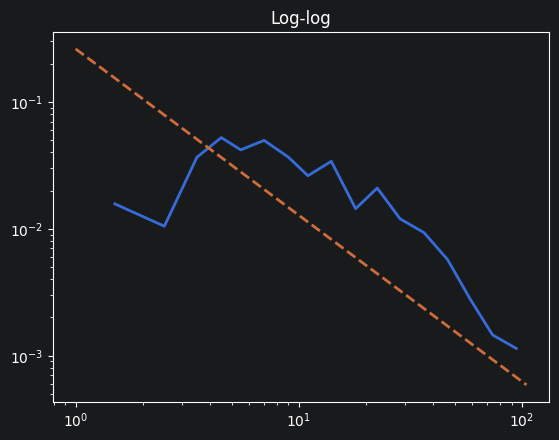

R: -153.9325256810805 p: 9.947489116144366e-46


In [7]:
import powerlaw

degrees = [d for _, d in C.degree() if d > 0]  # unweighted
fit = powerlaw.Fit(degrees, xmin=1, discrete=True)

ax = fit.plot_pdf(linewidth=2)
fit.power_law.plot_pdf(ax=ax, linestyle='--', linewidth=2)
plt.title("Log-log")
plt.show()

R, p = fit.distribution_compare('power_law', 'lognormal')
print("R:", R, "p:", p)

# R, p = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
# print (R, p)
# plt.figure(figsize=(10, 6))
# fit.distribution_compare('power_law', 'lognormal')
# fig4 = fit.plot_ccdf(linewidth=3, color='black')
# fit.power_law.plot_ccdf(ax=fig4, color='r', linestyle='--') #powerlaw
# fit.lognormal.plot_ccdf(ax=fig4, color='g', linestyle='--') #lognormal
# fit.stretched_exponential.plot_ccdf(ax=fig4, color='b', linestyle='--')

### Population and Degree/Strength Scatterplots

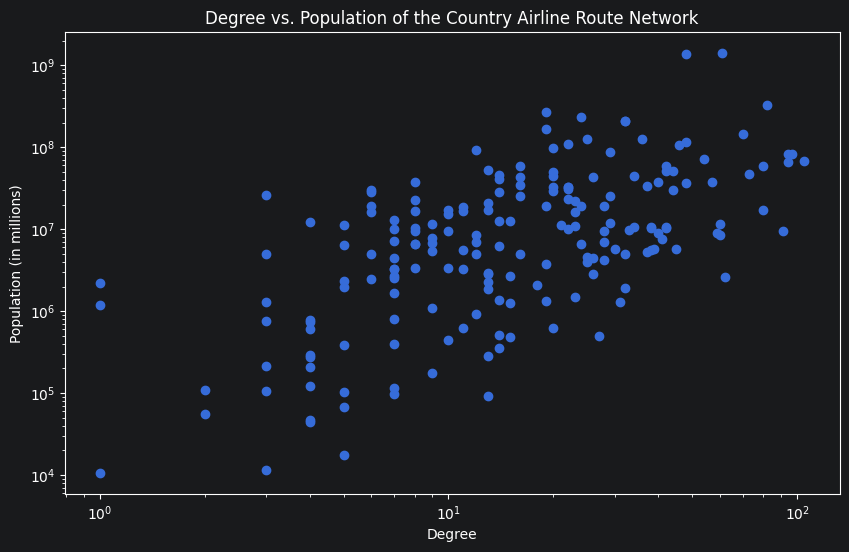

In [8]:
degrees = []
populations = []

for pair in C.degree():
    d = pair[1]
    p = int(C.nodes[pair[0]]["population"])
    degrees.append(d)
    populations.append(p)

plt.figure(figsize=(10, 6))
plt.scatter(degrees, populations)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree")
plt.ylabel("Population (in millions)")
plt.title(f"Degree vs. Population of the Country Airline Route Network")

plt.show()

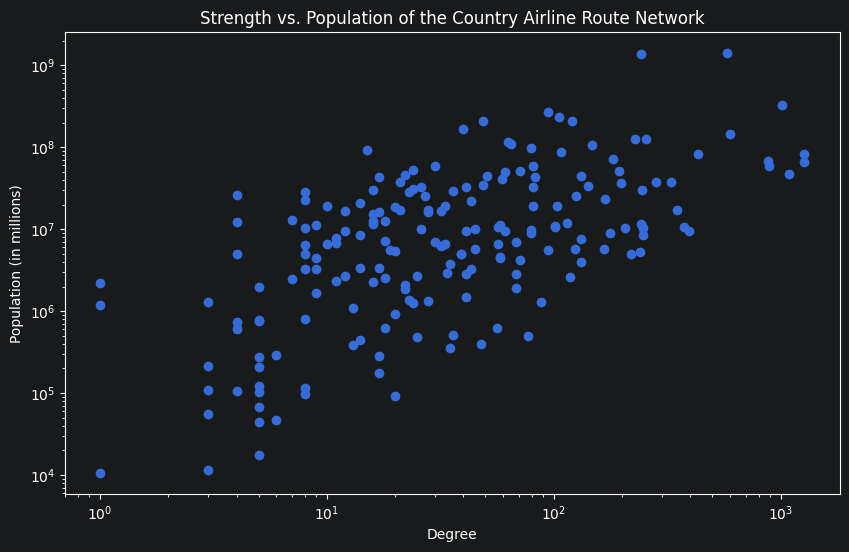

In [9]:
strength = []
populations = []

for pair in C.degree(weight='weight'):
    d = pair[1]
    p = int(C.nodes[pair[0]]["population"])
    strength.append(d)
    populations.append(p)

plt.figure(figsize=(10, 6))
plt.scatter(strength, populations)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree")
plt.ylabel("Population (in millions)")
plt.title(f"Strength vs. Population of the Country Airline Route Network")

plt.show()

## Finding Hubs

### Connectivity Hubs (many direct connections)

In [10]:
deg = dict(C.degree())
top_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:20]
top_deg

[('France', 105),
 ('Germany', 97),
 ('Turkey', 94),
 ('United Kingdom', 94),
 ('United Arab Emirates', 91),
 ('United States', 82),
 ('Netherlands', 80),
 ('Italy', 80),
 ('Spain', 73),
 ('Russia', 70),
 ('Qatar', 62),
 ('China', 61),
 ('Belgium', 60),
 ('Switzerland', 60),
 ('Austria', 59),
 ('Canada', 57),
 ('Thailand', 54),
 ('India', 48),
 ('Morocco', 48),
 ('Ethiopia', 48)]

### Traffic Hubs (many routes/heavy connections)

In [11]:
strength = dict(C.degree(weight="weight"))
top_strength = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:20]
top_strength

[('Germany', 1271),
 ('United Kingdom', 1267),
 ('Spain', 1091),
 ('United States', 1015),
 ('Italy', 891),
 ('France', 875),
 ('Russia', 595),
 ('China', 577),
 ('Turkey', 433),
 ('United Arab Emirates', 396),
 ('Greece', 374),
 ('Netherlands', 348),
 ('Canada', 329),
 ('Poland', 283),
 ('Japan', 255),
 ('Portugal', 247),
 ('Switzerland', 246),
 ('Saudi Arabia', 244),
 ('India', 243),
 ('Belgium', 243)]

### Transfer Hubs (bridge countries that sit on many shortest paths)

In [12]:
bc = nx.betweenness_centrality(C, normalized=True)
top_bc = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:20]
top_bc

[('United States', 0.14912537045244809),
 ('France', 0.10833924353795439),
 ('United Arab Emirates', 0.06479469133388858),
 ('Germany', 0.06093501594067622),
 ('United Kingdom', 0.05555470414061334),
 ('Turkey', 0.05289576119271986),
 ('South Africa', 0.04427236026473392),
 ('Spain', 0.04192874587080746),
 ('Netherlands', 0.041285662098040084),
 ('Australia', 0.0377834636341852),
 ('Canada', 0.030815868816224314),
 ('Kenya', 0.028362674107836255),
 ('China', 0.02792586173616296),
 ('Ethiopia', 0.025191234009563947),
 ('Morocco', 0.023817666952363703),
 ('Russia', 0.02239897105507683),
 ('Italy', 0.021623002412035765),
 ('Belgium', 0.02044139882411142),
 ('South Korea', 0.01915977194337118),
 ('Qatar', 0.01748550190361819)]

### Find Frequent Countries Across Metrics

In [13]:
def top_pct(d, pct=0.1):
    k = max(1, int(len(d) * pct))
    return set([n for n, _ in sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]])

deg = dict(C.degree())
strength = dict(C.degree(weight="weight"))

import networkx as nx
bc = nx.betweenness_centrality(C, normalized=True)

hub_candidates = (top_pct(deg, 0.1) |
                  top_pct(strength, 0.1) |
                  top_pct(bc, 0.1))

# Count how many lists each node appears in
scores = {}
for n in hub_candidates:
    scores[n] = sum([
        n in top_pct(deg, 0.1),
        n in top_pct(strength, 0.1),
        n in top_pct(bc, 0.1)
    ])

sorted(scores.items(), key=lambda x: x[1], reverse=True)[:30]

hub_c = []
for s in scores.items():
    if s[1] ==3:
        hub_c.append(s[0])

print(hub_c)
print(len(hub_c))

['France', 'Netherlands', 'Turkey', 'United States', 'Italy', 'United Kingdom', 'United Arab Emirates', 'Russia', 'Germany', 'Spain', 'Canada', 'China']
12


### Nodes with Degree N

In [14]:
n = 105
node_w_degree = [node for node, degree in C.degree() if degree == n]
print(f"Countries with degree {n}: {node_w_degree}")

Countries with degree 105: ['France']


### Degree and Strength by Name

In [15]:
for name, _ in C.degree():
    print(f"{name} Degree: {C.degree(name)}")
    print(f"{name} Strength: {C.degree(name, weight='weight')}\n")

Nigeria Degree: 32
Nigeria Strength: 49

Seychelles Degree: 7
Seychelles Strength: 8

Saint Lucia Degree: 9
Saint Lucia Strength: 17

Niger Degree: 8
Niger Strength: 8

Jordan Degree: 34
Jordan Strength: 57

Somalia Degree: 6
Somalia Strength: 17

Laos Degree: 7
Laos Strength: 18

Tuvalu Degree: 1
Tuvalu Strength: 1

Gambia Degree: 6
Gambia Strength: 7

Tonga Degree: 3
Tonga Strength: 4

Antigua and Barbuda Degree: 13
Antigua and Barbuda Strength: 20

Jamaica Degree: 13
Jamaica Strength: 41

Bahrain Degree: 23
Bahrain Strength: 41

Zambia Degree: 11
Zambia Strength: 20

Palau Degree: 5
Palau Strength: 5

Azerbaijan Degree: 22
Azerbaijan Strength: 45

Congo (Kinshasa) Degree: 12
Congo (Kinshasa) Strength: 15

Congo (Brazzaville) Degree: 11
Congo (Brazzaville) Strength: 19

Guatemala Degree: 10
Guatemala Strength: 21

Chile Degree: 19
Chile Strength: 33

Latvia Degree: 32
Latvia Strength: 68

Armenia Degree: 13
Armenia Strength: 34

Czech Republic Degree: 38
Czech Republic Strength: 101


### Edge Weight by Name

In [16]:
weights = nx.get_edge_attributes(C, 'weight')
edge = ("Egypt", "France")
if edge not in list(C.edges()):
    print(f"No flights are offered between {edge[0]} and {edge[1]}.")
else:
    print(f"Number of flights between {edge[0]} and {edge[1]}: {weights[edge]}")

No flights are offered between Egypt and France.


### Edges with Weight

In [17]:
w = 1
edges_w_weight = [edge for edge in C.edges(data=True) if edge[2]['weight'] == w]
print(f"Edges with weight {w}: {edges_w_weight}")

Edges with weight 1: [('Nigeria', 'Mali', {'weight': 1}), ('Nigeria', 'Senegal', {'weight': 1}), ('Nigeria', 'Niger', {'weight': 1}), ('Nigeria', 'Cameroon', {'weight': 1}), ('Nigeria', 'Liberia', {'weight': 1}), ('Nigeria', 'Morocco', {'weight': 1}), ('Nigeria', 'Italy', {'weight': 1}), ('Nigeria', 'Gabon', {'weight': 1}), ('Nigeria', 'Spain', {'weight': 1}), ('Nigeria', 'Netherlands', {'weight': 1}), ('Nigeria', 'Kenya', {'weight': 1}), ('Nigeria', 'Qatar', {'weight': 1}), ('Nigeria', 'Jordan', {'weight': 1}), ('Nigeria', 'South Africa', {'weight': 1}), ('Nigeria', 'Sierra Leone', {'weight': 1}), ('Nigeria', 'Rwanda', {'weight': 1}), ('Nigeria', 'Saudi Arabia', {'weight': 1}), ('Nigeria', 'Sudan', {'weight': 1}), ('Seychelles', 'Kenya', {'weight': 1}), ('Seychelles', 'Russia', {'weight': 1}), ('Seychelles', 'Germany', {'weight': 1}), ('Seychelles', 'South Africa', {'weight': 1}), ('Seychelles', 'Sri Lanka', {'weight': 1}), ('Seychelles', 'Mauritius', {'weight': 1}), ('Saint Lucia', '

### Connectivity per Capita

In [18]:
for country, _ in C.degree():
    access = int(C.degree(country))/(int(C.nodes[country]["population"])/1000000)
    fairness = int(C.degree(country, weight="weight"))/(int(C.nodes[country]["population"])/1000000)
    print(f"Access of {country}: {access:.2f}\nFairness of {country}: {fairness:.2f}\n")

Access of Nigeria: 0.15
Fairness of Nigeria: 0.23

Access of Seychelles: 71.70
Fairness of Seychelles: 81.95

Access of Saint Lucia: 50.66
Fairness of Saint Lucia: 95.69

Access of Niger: 0.35
Fairness of Niger: 0.35

Access of Jordan: 3.19
Fairness of Jordan: 5.34

Access of Somalia: 0.37
Fairness of Somalia: 1.06

Access of Laos: 0.97
Fairness of Laos: 2.49

Access of Tuvalu: 94.51
Fairness of Tuvalu: 94.51

Access of Gambia: 2.44
Fairness of Gambia: 2.85

Access of Tonga: 28.39
Fairness of Tonga: 37.85

Access of Antigua and Barbuda: 142.29
Fairness of Antigua and Barbuda: 218.90

Access of Jamaica: 4.60
Fairness of Jamaica: 14.52

Access of Bahrain: 15.50
Fairness of Bahrain: 27.63

Access of Zambia: 0.59
Fairness of Zambia: 1.08

Access of Palau: 280.93
Fairness of Palau: 280.93

Access of Azerbaijan: 2.19
Fairness of Azerbaijan: 4.49

Access of Congo (Kinshasa): 0.13
Fairness of Congo (Kinshasa): 0.16

Access of Congo (Brazzaville): 1.96
Fairness of Congo (Brazzaville): 3.38

Acc

In [19]:
world_pop = 7778008621

for country, _ in C.degree():
    print(f"{country} Population: {C.nodes[country]["population"]}")
    print(f"{country} Airports: {C.nodes[country]["airports"]}")
    print(f"{country} Proportion: {(int(C.nodes[country]["population"]) / world_pop)*100:.2f}%")
    print()


Nigeria Population: 209485641
Nigeria Airports: 18
Nigeria Proportion: 2.69%

Seychelles Population: 97625
Seychelles Airports: 2
Seychelles Proportion: 0.00%

Saint Lucia Population: 177661
Saint Lucia Airports: 2
Saint Lucia Proportion: 0.00%

Niger Population: 22947757
Niger Airports: 1
Niger Proportion: 0.30%

Jordan Population: 10671891
Jordan Airports: 2
Jordan Proportion: 0.14%

Somalia Population: 16030971
Somalia Airports: 5
Somalia Proportion: 0.21%

Laos Population: 7237636
Laos Airports: 8
Laos Proportion: 0.09%

Tuvalu Population: 10581
Tuvalu Airports: 1
Tuvalu Proportion: 0.00%

Gambia Population: 2456844
Gambia Airports: 1
Gambia Proportion: 0.03%

Tonga Population: 105669
Tonga Airports: 1
Tonga Proportion: 0.00%

Antigua and Barbuda Population: 91364
Antigua and Barbuda Airports: 1
Antigua and Barbuda Proportion: 0.00%

Jamaica Population: 2823271
Jamaica Airports: 2
Jamaica Proportion: 0.04%

Bahrain Population: 1483756
Bahrain Airports: 1
Bahrain Proportion: 0.02%



### Lorenz Curve and Gini Coefficient Computation

Gini coefficient: 0.7365668285516077


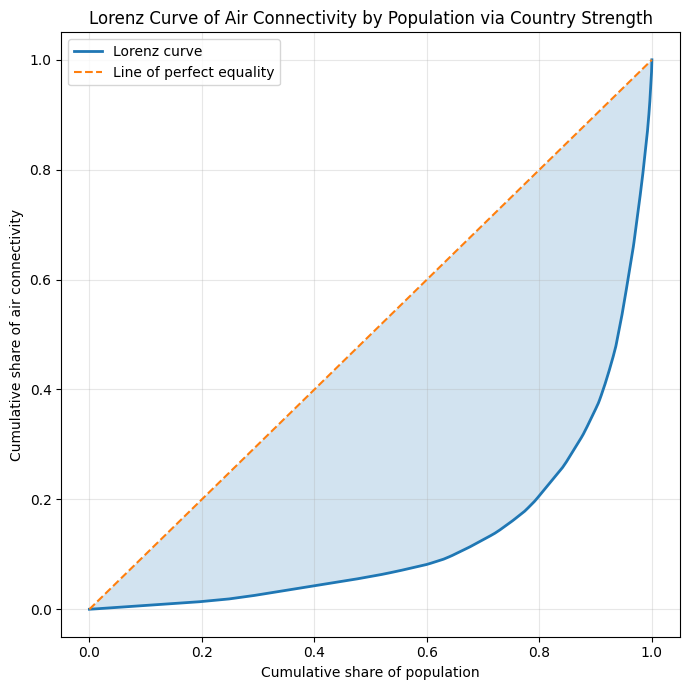

In [48]:
def lorenz_curve_and_gini(C):
    strength = dict(C.degree(weight="weight"))

    # Get population and strength data
    data = []
    for node in C.nodes():
        pop = int(C.nodes[node]["population"])
        s = strength.get(node, 0)
        ratio = s / pop
        data.append((node, pop, s, ratio))

    # Sort countries by connectivity per capita (lowest to highest)
    data.sort(key=lambda x: x[3])

    pop = data.copy()
    pop.sort(key=lambda x: x[1])

    # Identify bottom N countries
    N = 5
    underserved = data[:N]

    # print("Most underserved countries:")
    # for country in underserved:
    #     print(country[0], country[3])

    populations = np.array([x[1] for x in data], dtype=float)
    strengths = np.array([x[2] for x in data], dtype=float)
    countries = [x[0] for x in data]

    # # Compare underserved to highest population
    # most_pop = pop[-10:]
    # for country in most_pop:
    #     print(country[0], country[1])

    total_pop = populations.sum()
    total_strength = strengths.sum()

    # Cumulative population share and cumulative connectivity share
    cum_pop_share = np.cumsum(populations) / total_pop
    cum_strength_share = np.cumsum(strengths) / total_strength

    # Add origin (0,0) for plotting and area calculation
    x = np.insert(cum_pop_share, 0, 0)
    y = np.insert(cum_strength_share, 0, 0)

    # Gini coefficient from the Lorenz curve
    # Gini = 1 - 2 * area under Lorenz curve
    area_under_curve = np.trapezoid(y, x)
    gini = 1 - 2 * area_under_curve

    return {
        "countries_sorted": countries,
        "populations": populations,
        "strengths": strengths,
        "cum_pop_share": x,
        "cum_strength_share": y,
        "gini": gini,
    }


def plot_lorenz(result, title="Lorenz Curve of Air Connectivity by Population via Country Strength"):
    x = result["cum_pop_share"]
    y = result["cum_strength_share"]

    plt.figure(figsize=(7, 7))
    plt.plot(x, y, label="Lorenz curve", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Line of perfect equality")
    plt.fill_between(x, y, x, alpha=0.2)

    plt.xlabel("Cumulative share of population")
    plt.ylabel("Cumulative share of air connectivity")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


result = lorenz_curve_and_gini(C)
print("Gini coefficient:", result["gini"])
plot_lorenz(result)

In [47]:
country = "North Korea"
for node, degree in C.degree(weight="weight"):
    if node == country:
        print(country, degree)

North Korea 4
